In [1]:
import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3
from huggingface_hub import InferenceClient

load_dotenv()

hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

print("all libraries are loaded successfully!")

e:\Yossra_aminFiles\New folder\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


all libraries are loaded successfully!


In [11]:
import os
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv(override=True)

# Callin OpenAI key
openai_api_key = os.getenv("OPENAI_API_KEY")

if openai_api_key:
    print(f"OpenAI API Key exists and begins with: {openai_api_key[:7]}...")
else:
    print("OpenAI API Key is not set!")

# Initializing the OpenAI Client
client = OpenAI(api_key=openai_api_key)

# Defining a light model from OpenAI
MODEL = "gpt-4o-mini"  # or gpt-3.5-turbo depending on your account

OpenAI API Key exists and begins with: sk-proj...


In [12]:
# Cell extra: creating a local database for airline flights and prices
import sqlite3

# 1. connection to the database (it will be created automatically if it doesn't exist)
conn = sqlite3.connect("airline_prices.db")
cursor = conn.cursor()

# 2. create the flights and prices table
cursor.execute('''
CREATE TABLE IF NOT EXISTS flights (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    flight_number TEXT,
    destination TEXT,
    departure_time TEXT,
    price REAL,
    baggage_allowance TEXT
)
''')

# 3. insert some sample data (you can modify it as you want)
sample_data = [
    ("MS-101", "Cairo to Dubai", "10:00 AM", 350.0, "30 kg"),
    ("MS-202", "Cairo to London", "02:30 PM", 600.0, "23 kg"),
    ("MS-303", "Cairo to Paris", "08:15 AM", 550.0, "23 kg"),
    ("MS-404", "Cairo to Jeddah", "11:45 PM", 200.0, "40 kg")
]

# make sure to not repeat the data if we run the cell more than once
cursor.execute("DELETE FROM flights")
cursor.executemany("INSERT INTO flights (flight_number, destination, departure_time, price, baggage_allowance) VALUES (?, ?, ?, ?, ?)", sample_data)

# save the changes and close the connection
conn.commit()
conn.close()

print("the database is created and the flights data is added successfully!")

the database is created and the flights data is added successfully!


In [13]:
system_message = """
You are a helpful and polite customer service assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 2 sentences.
Always be accurate. If you don't know the answer, say so clearly.
"""

In [14]:
def get_flight_info(destination_city):
    print(f"DATABASE TOOL CALLED: Searching for flights to {destination_city}", flush=True)
    
    with sqlite3.connect("airline_prices.db") as conn:
        cursor = conn.cursor()
        
        cursor.execute('SELECT flight_number, departure_time, price, baggage_allowance FROM flights WHERE destination LIKE ?', (f"%{destination_city}%",))
        result = cursor.fetchone()
        
        if result:
            flight_no, dep_time, price, baggage = result
            return f"Flight {flight_no} to {destination_city} departs at {dep_time}, costs ${price}, and includes {baggage} baggage allowance."
        else:
            return f"No available flights found for {destination_city}."

In [15]:
test_result = get_flight_info("Dubai")
print(test_result)

DATABASE TOOL CALLED: Searching for flights to Dubai
Flight MS-101 to Dubai departs at 10:00 AM, costs $350.0, and includes 30 kg baggage allowance.


In [16]:
price_function = {
    "name": "get_flight_info",
    "description": "Get the flight details, price, and schedule to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            }
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}

tools = [{"type": "function", "function": price_function}]

print("the tool is defined successfully!")

the tool is defined successfully!


In [18]:
import json

def chat(message, history):
    messages = [{"role": "system", "content": system_message}] + \
               [{"role": "user" if i%2==0 else "assistant", "content": m} for sublist in history for i, m in enumerate(sublist)] + \
               [{"role": "user", "content": message}]
    
    response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    while response.choices[0].finish_reason == "tool_calls":
        msg = response.choices[0].message
        messages.append(msg)
        for t in msg.tool_calls:
            res = get_flight_info(json.loads(t.function.arguments).get("destination_city"))
            messages.append({"role": "tool", "tool_call_id": t.id, "content": res})
        response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)
        
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, title="✈️ FlightAI Assistant").launch(inline=True)

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "e:\Yossra_aminFiles\New folder\Lib\site-packages\gradio\queueing.py", line 882, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "e:\Yossra_aminFiles\New folder\Lib\site-packages\gradio\route_utils.py", line 417, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<12 lines>...
    )
    ^
  File "e:\Yossra_aminFiles\New folder\Lib\site-packages\gradio\blocks.py", line 2430, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<9 lines>...
    )
    ^
  File "e:\Yossra_aminFiles\New folder\Lib\site-packages\gradio\blocks.py", line 1696, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Yossra_aminFiles\New folder\Lib\site-packages\gradio\utils.py", line

In [19]:
import json

def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    while response.choices[0].finish_reason == "tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)
        
    return response.choices[0].message.content

In [20]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [22]:
gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "e:\Yossra_aminFiles\New folder\Lib\site-packages\gradio\queueing.py", line 882, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "e:\Yossra_aminFiles\New folder\Lib\site-packages\gradio\route_utils.py", line 417, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<12 lines>...
    )
    ^
  File "e:\Yossra_aminFiles\New folder\Lib\site-packages\gradio\blocks.py", line 2430, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<9 lines>...
    )
    ^
  File "e:\Yossra_aminFiles\New folder\Lib\site-packages\gradio\blocks.py", line 1696, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Yossra_aminFiles\New folder\Lib\site-packages\gradio\utils.py", line

In [23]:
def artist(city):
    image = hf_client.text_to_image(
        prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style",
        model="black-forest-labs/FLUX.1-schnell"
    )
    return image

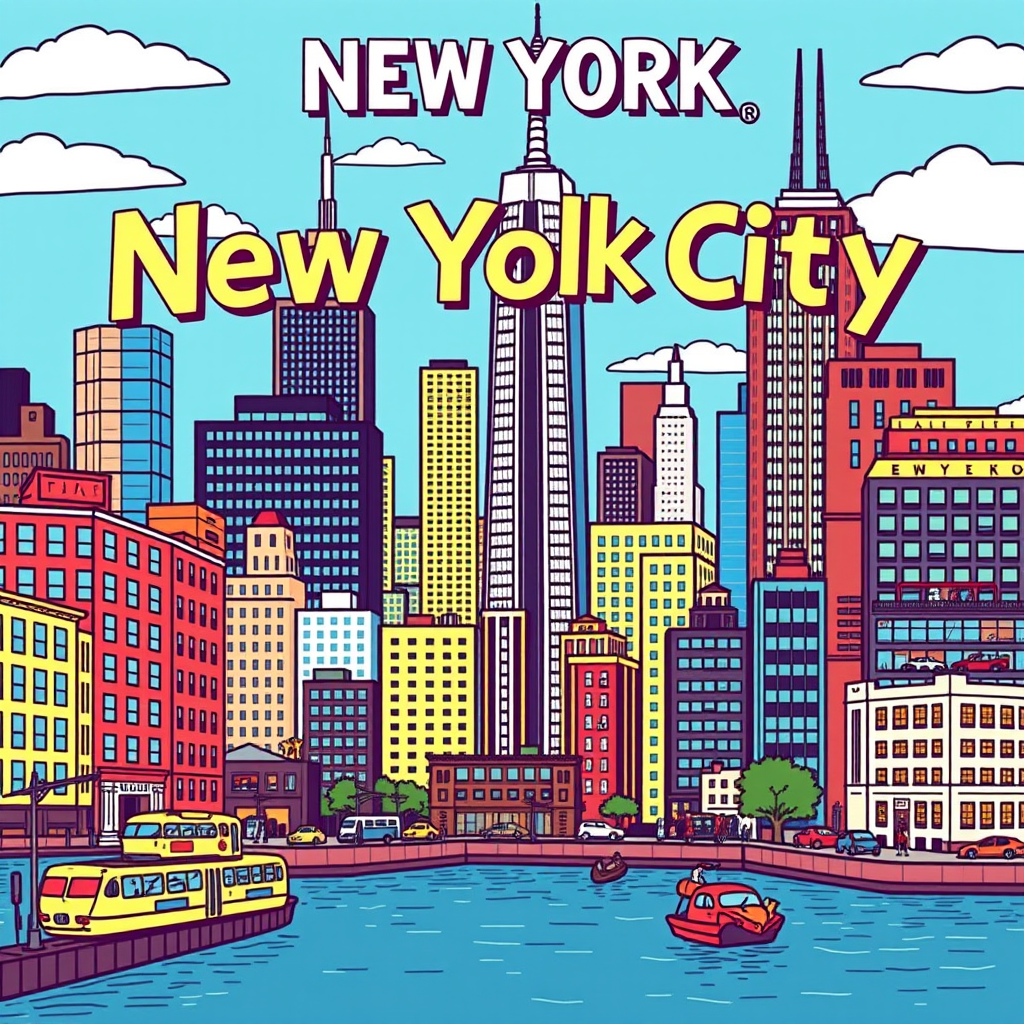

In [24]:
image = artist("New York City")
display(image)

In [25]:
def talker(message):
    audio_bytes = hf_client.text_to_speech(
        text=message,
        model="hexgrad/Kokoro-82M"
    )
    return audio_bytes

In [26]:
def chat(history):
    # Formatting the previous conversation log to include the role and content
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    
    # Collecting the system message and the conversation log to send to the model
    messages = [{"role": "system", "content": system_message}] + history
    
    # Sending the first request using the default OpenAI client (client)
    response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = None
    
    # Looping to handle any tool calls requested by the model
    while response.choices[0].finish_reason == "tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        
        # Calling the model again after providing the tool results
        response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)
        
    # Extracting the final reply and adding it to the log
    reply = response.choices[0].message.content
    history += [{"role": "assistant", "content": reply}]
    
    # Converting the text reply to speech using the talker tool
    voice = talker(reply)
    
    # If a city was found through the search, the image is drawn using the artist tool
    if cities:
        image = artist(cities[0])
        
    return history, voice, image

In [27]:
import json

def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
       
        if tool_call.function.name == "get_flight_info":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            
            # استدعاء دالة قاعدة البيانات
            price_details = get_flight_info(city)
            
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

In [30]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
    return "", history + [{"role": "user", "content": message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500)
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

    message.submit(
        put_message_in_chatbot, 
        inputs=[message, chatbot], 
        outputs=[message, chatbot]
    ).then(
        chat, 
        inputs=chatbot, 
        outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("yossra", "amin"))

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.
